# Tuning the pivoting tolerances of `linprog_simplex`: 2026 rerun on current `main`

This notebook analyzes a rerun of the 2020 tuning study on the current code (QuantEcon.py 0.11.4,
after the 2024 Phase 1 fix and the 2026 vectorization of `_pivoting`), with the following changes:

- **Success criterion.** A solve counts as *solved* when the objective value matches the
  reference optimum to a relative error below `1e-6` (or absolute error below `1e-6`), regardless of
  the `success` flag returned. The reference is the Netlib optimal value stored in the `.npz` files,
  cross-checked against scipy's HiGHS (`reference_optima.csv`).
- **Grid.** Since the 2020 study showed that `fea_tol` and `tol_ratio_diff` hardly matter, the grid is
  `fea_tol` in {1e-5, 1e-6, 1e-7} x `tol_piv` in {1e-3, ..., 1e-10} x `tol_ratio_diff` in {1e-11, 1e-13, 1e-15}
  (72 combinations), `max_iter = 10_000`, on the 51 problems of the 2020 study excluding the three
  giants QAP12, QAP15 and STOCFOR3 (`results_2026.csv`).
- **Giants.** QAP12, QAP15 and STOCFOR3 were run only along `tol_piv` with the other tolerances at
  1e-6 and 1e-13 (`results_2026_large.csv`).
- **Iteration budget.** The problems that hit `max_iter` at the leading combinations were rerun with
  `max_iter = 100_000` (`results_2026_maxiter.csv`).

Data were produced by `run_grid.py` (10 parallel workers on an Apple M-series laptop; timings are
indicative only).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
TOL = 1e-6
FMT = {c: '{:.0e}'.format for c in ['fea_tol', 'tol_piv', 'tol_ratio_diff']}


# Reference optimal values: HiGHS where available, else the Netlib value stored in the .npz file
ref = pd.read_csv('reference_optima.csv')
OBJ_REF = ref.set_index('problem')['obj_ref']


def classify(d, tol=TOL):
    """Add columns obj_ref, rel_err, solved and category to a results table."""
    d = d.copy()
    d['obj_ref'] = d['problem'].map(OBJ_REF)
    d['rel_err'] = np.abs(d['fun'] / d['obj_ref'] - 1)
    d['solved'] = (d['rel_err'] < tol) | (np.abs(d['fun'] - d['obj_ref']) < tol)
    c = pd.Series('', index=d.index)
    c[d.success & d.solved] = '1 solved'
    c[d.success & ~d.solved & (d.rel_err < 1e-4)] = '2a success, value slightly off'
    c[d.success & ~d.solved & (d.rel_err >= 1e-4)] = '2b success, value wrong'
    c[d.status == 3] = '3 false unbounded'
    c[d.status == 2] = '4 false infeasible'
    c[(d.status == 1) & d.solved] = '5a max_iter, value correct'
    c[(d.status == 1) & ~d.solved] = '5b max_iter, value not correct'
    d['category'] = c
    return d


df = classify(pd.read_csv('results_2026.csv'))
problems = sorted(df.problem.unique())
print(df.param_idx.nunique(), 'combinations x', len(problems), 'problems =', len(df), 'solves')

72 combinations x 51 problems = 3672 solves


## Reference optimal values

The optimal values stored in the `.npz` files (from Netlib) agree with scipy's HiGHS to about 1e-11 on
almost all problems. The exceptions are SCRS8 and STOCFOR3, where HiGHS differs by 3e-6, and
`linprog_simplex` agrees with HiGHS there. HiGHS values are therefore used as reference (`obj_ref`);
for QAP15, which HiGHS did not finish in the time allowed, the Netlib value is used. All values are
for the maximization form, i.e. the negated Netlib minimum.

In [2]:
ref.sort_values('rel_diff', ascending=False).head(6)

,problem,obj_netlib,obj_highs,obj_ref,rel_diff
33,SCRS8,-9.043000e+02,-9.042970e+02,-9.042970e+02,3.353300e-06
50,STOCFOR3,3.997666e+04,3.997678e+04,3.997678e+04,3.060977e-06
28,SCAGR7,2.331389e+06,2.331390e+06,2.331390e+06,2.442882e-07
12,D2Q06C,-1.227842e+05,-1.227842e+05,-1.227842e+05,2.063442e-07
9,BNL1,-1.977629e+03,-1.977630e+03,-1.977630e+03,1.395220e-07
16,FFFFF800,-5.556796e+05,-5.556796e+05,-5.556796e+05,8.427969e-08


## Current defaults on all 54 problems

`results_2026_defaults.csv` is a single pass with the current defaults `PivOptions(1e-6, 1e-7, 1e-13)`
over all 54 problems (including the three giants), `max_iter = 10_000`.

In [3]:
dflt = classify(pd.read_csv('results_2026_defaults.csv'))
print(dflt.solved.sum(), 'of', len(dflt), 'solved')
dflt[~dflt.solved].set_index('problem')[['category', 'status', 'num_iter', 'rel_err', 'exec_time']].sort_values('category')

38 of 54 solved


,category,status,num_iter,rel_err,exec_time
problem,,,,,
WOOD1P,3 false unbounded,3,130,inf,0.013712
WOODW,3 false unbounded,3,513,inf,0.499123
25FV47,3 false unbounded,3,6248,inf,3.056575
SCTAP3,3 false unbounded,3,987,inf,1.409621
SCSD8,3 false unbounded,3,747,inf,0.103454
SCTAP2,3 false unbounded,3,330,inf,0.099715
D2Q06C,3 false unbounded,3,9293,inf,47.293122
FFFFF800,4 false infeasible,2,1450,inf,0.126452
DEGEN3,"5b max_iter, value not correct",1,10000,inf,24.298723


## Sensitivity to the closeness threshold

Mean number of solved problems per combination as a function of the threshold.

In [4]:
pd.Series({tol: classify(df, tol).groupby('param_idx').solved.sum().mean()
           for tol in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]}, name='mean solved per combination')

1.000000e-02    38.222222
1.000000e-04    37.819444
1.000000e-06    37.236111
1.000000e-08    37.000000
1.000000e-10    36.597222
Name: mean solved per combination, dtype: float64

## Reported `success` versus actual correctness

In [5]:
pd.crosstab(df.success, df.solved, rownames=['success flag'], colnames=['solved (value correct)'])

solved (value correct),False,True
success flag,,
False,900,0
True,91,2681


In [6]:
# Solves that report success with a wrong value: which problems, and how wrong
fp = df[df.success & ~df.solved]
fp.groupby('problem').rel_err.agg(['count', 'min', 'median', 'max']).style.format('{:.2e}', subset=['min', 'median', 'max'])

,count,min,median,max
problem,,,,
AGG,9,8.93e-03,9.16e-02,9.16e-02
AGG3,9,1.61e-05,1.61e-05,1.61e-05
BANDM,3,9.10e+13,9.10e+13,9.10e+13
BRANDY,6,1.49e-05,1.49e-05,1.49e-05
DEGEN2,3,1.17e-02,1.17e-02,1.17e-02
FFFFF800,6,6.16e-06,6.16e-06,6.16e-06
ISRAEL,9,1.00e-04,1.00e-04,6.59e-04
LOTFI,6,2.74e-03,1.43e-02,2.58e-02
SCAGR25,19,4.79e-06,2.43e-05,3.10e+09


## Marginal effect of each tolerance

Mean number of solved problems (out of 51) per combination, by the value of one tolerance, together
with the mean total runtime of a combination.

In [7]:
for c in ['fea_tol', 'tol_piv', 'tol_ratio_diff']:
    g = df.groupby([c, 'param_idx']).agg(solved=('solved', 'sum'), minutes=('exec_time', 'sum'))
    g['minutes'] /= 60
    display(g.groupby(level=0).agg(mean_solved=('solved', 'mean'), min_solved=('solved', 'min'),
                                   max_solved=('solved', 'max'), minutes=('minutes', 'mean')).round(2))

,mean_solved,min_solved,max_solved,minutes
fea_tol,,,,
1.000000e-07,37.25,29,43,7.07
1.000000e-06,37.42,29,43,7.15
1.000000e-05,37.04,29,43,7.06


,mean_solved,min_solved,max_solved,minutes
tol_piv,,,,
1.000000e-10,29.67,29,31,3.94
1.000000e-09,34.33,33,36,5.63
1.000000e-08,35.67,35,36,6.75
1.000000e-07,37.67,37,38,6.60
1.000000e-06,40.00,39,41,7.97
1.000000e-05,40.89,39,43,8.87
1.000000e-04,41.89,41,43,8.60
1.000000e-03,37.78,35,42,8.36


,mean_solved,min_solved,max_solved,minutes
tol_ratio_diff,,,,
1.000000e-15,36.67,29,42,7.28
1.000000e-13,37.00,31,42,7.31
1.000000e-11,38.04,29,43,6.68


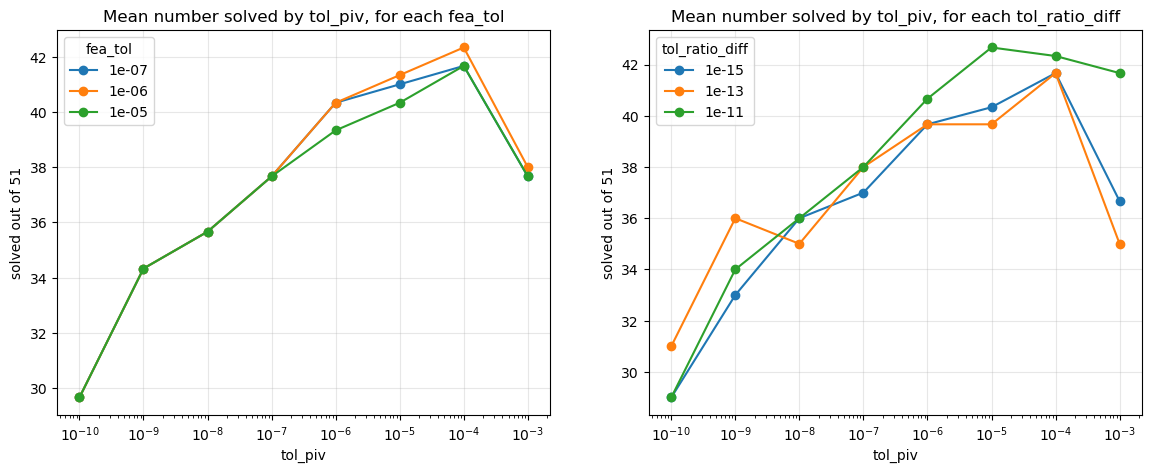

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, other in zip(axes, ['fea_tol', 'tol_ratio_diff']):
    t = df.groupby([other, 'tol_piv', 'param_idx']).solved.sum().groupby(level=[0, 1]).mean().unstack(0)
    t.plot(ax=ax, marker='o', logx=True)
    ax.set_title(f'Mean number solved by tol_piv, for each {other}')
    ax.set_ylabel('solved out of 51'); ax.grid(alpha=.3)

## Failure categories by `tol_piv`

Share of the 153 solves at each value of `tol_piv` (3 x 3 combinations x 17 problems... i.e. 9 combinations x 51 problems / 3).

In [9]:
shares = pd.crosstab(df.category, df.tol_piv, normalize='columns').mul(100).round(0).astype(int)
shares.columns = [f'{c:.0e}' for c in shares.columns]
shares

,1e-10,1e-09,1e-08,1e-07,1e-06,1e-05,1e-04,1e-03
category,,,,,,,,
1 solved,58,67,70,74,78,80,82,74
"2a success, value slightly off",0,1,2,1,1,0,0,4
"2b success, value wrong",1,1,0,1,0,1,1,6
3 false unbounded,36,25,16,12,7,3,1,1
4 false infeasible,1,0,0,2,1,1,1,1
"5b max_iter, value not correct",3,7,12,10,14,15,14,14


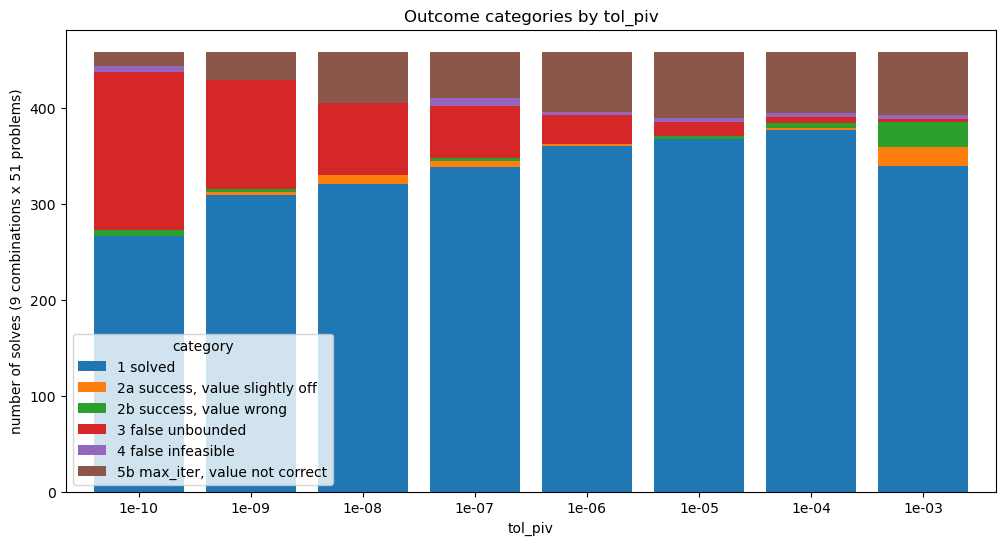

In [10]:
ax = pd.crosstab(df.tol_piv, df.category).plot.bar(stacked=True, figsize=(12, 6), width=.8)
ax.set_xticklabels([f'{float(t.get_text()):.0e}' for t in ax.get_xticklabels()], rotation=0)
ax.set_ylabel('number of solves (9 combinations x 51 problems)'); ax.set_title('Outcome categories by tol_piv');

## Per-problem view

In [11]:
per_problem = (df.groupby('problem')
               .agg(solved=('solved', 'mean'), success=('success', 'mean'),
                    unbounded=('status', lambda s: (s == 3).mean()),
                    infeasible=('status', lambda s: (s == 2).mean()),
                    max_iter=('status', lambda s: (s == 1).mean()),
                    mean_sec=('exec_time', 'mean'))
               .sort_values('solved'))
per_problem[per_problem.solved < 1].round(3)

,solved,success,unbounded,infeasible,max_iter,mean_sec
problem,,,,,,
25FV47,0.000,0.000,0.333,0.000,0.667,11.258
TRUSS,0.000,0.000,0.292,0.000,0.708,64.973
QAP8,0.000,0.000,0.208,0.000,0.792,15.232
DEGEN3,0.000,0.000,0.000,0.000,1.000,46.676
D2Q06C,0.000,0.000,0.333,0.000,0.667,82.697
BNL2,0.000,0.000,0.208,0.000,0.792,70.825
WOOD1P,0.042,0.125,0.792,0.000,0.083,0.192
SCTAP2,0.125,0.125,0.583,0.000,0.292,9.683
SCTAP3,0.208,0.208,0.625,0.000,0.167,14.984


In [12]:
# Solved rate by tol_piv for the problems that are not always solved
t = df.pivot_table(index='problem', columns='tol_piv', values='solved', aggfunc='mean')
t = t[(t < 1).any(axis=1)]
t.columns = [f'{c:.0e}' for c in t.columns]
t.round(2).style.background_gradient(cmap='RdYlGn', vmin=0, vmax=1)

,1e-10,1e-09,1e-08,1e-07,1e-06,1e-05,1e-04,1e-03
problem,,,,,,,,
25FV47,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AGG,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
AGG3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
BANDM,0.330000,0.670000,0.670000,0.670000,1.000000,0.890000,1.000000,0.890000
BNL1,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
BNL2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BRANDY,0.330000,0.670000,0.670000,0.670000,0.670000,1.000000,0.890000,1.000000
D2Q06C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DEGEN2,0.670000,0.670000,0.670000,0.670000,0.670000,0.670000,0.670000,0.670000


## Best combinations

Maximize the number of solved problems; break ties by total runtime.

In [13]:
agg = (df.groupby(['param_idx', 'fea_tol', 'tol_piv', 'tol_ratio_diff'])
         .agg(solved=('solved', 'sum'), success=('success', 'sum'), minutes=('exec_time', 'sum'))
         .reset_index())
agg['minutes'] /= 60
agg.sort_values(['solved', 'minutes'], ascending=[False, True]).head(10).style.format(FMT | {'minutes': '{:.1f}'})

,param_idx,fea_tol,tol_piv,tol_ratio_diff,solved,success,minutes
3,3,1e-05,1e-04,1e-11,43,43,8.2
54,54,1e-07,1e-05,1e-11,43,43,8.3
30,30,1e-06,1e-05,1e-11,43,43,8.4
27,27,1e-06,1e-04,1e-11,43,44,8.4
6,6,1e-05,1e-05,1e-11,42,42,8.2
24,24,1e-06,1e-03,1e-11,42,45,8.3
48,48,1e-07,1e-03,1e-11,42,45,8.3
28,28,1e-06,1e-04,1e-13,42,43,8.6
52,52,1e-07,1e-04,1e-13,42,43,8.7
53,53,1e-07,1e-04,1e-15,42,43,8.7


In [14]:
defaults = (1e-6, 1e-7, 1e-13)
is_default = (np.isclose(agg.fea_tol, defaults[0], rtol=1e-3, atol=0) & np.isclose(agg.tol_piv, defaults[1], rtol=1e-3, atol=0)
              & np.isclose(agg.tol_ratio_diff, defaults[2], rtol=1e-3, atol=0))
print('Current defaults:'); agg[is_default].style.format(FMT | {'minutes': '{:.1f}'})

Current defaults:


,param_idx,fea_tol,tol_piv,tol_ratio_diff,solved,success,minutes
37,37,1e-06,1e-07,1e-13,38,38,7.1


In [15]:
best = (1e-6, 1e-5, 1e-11)
def outcome(params):
    sel = df[np.isclose(df.fea_tol, params[0], rtol=1e-3, atol=0) & np.isclose(df.tol_piv, params[1], rtol=1e-3, atol=0)
             & np.isclose(df.tol_ratio_diff, params[2], rtol=1e-3, atol=0)]
    return sel.set_index('problem')[['category', 'rel_err', 'num_iter', 'exec_time']]
cmp = outcome(defaults).join(outcome(best), lsuffix='_default', rsuffix='_best')
cmp[cmp.category_default != cmp.category_best].sort_values('category_default')

,category_default,rel_err_default,num_iter_default,exec_time_default,category_best,rel_err_best,num_iter_best,exec_time_best
problem,,,,,,,,
D2Q06C,3 false unbounded,inf,9293,100.667228,"5b max_iter, value not correct",inf,10000,114.070261
WOODW,3 false unbounded,inf,513,1.276011,1 solved,2.106315e-12,3699,23.752323
25FV47,3 false unbounded,inf,6248,9.271197,"5b max_iter, value not correct",6.525166e-01,10000,15.858579
SCTAP3,3 false unbounded,inf,987,2.713959,1 solved,4.147793e-13,6978,31.899921
SCSD8,3 false unbounded,inf,747,0.297621,1 solved,4.440892e-15,1998,0.993159
FFFFF800,4 false infeasible,inf,1450,0.212674,1 solved,2.065015e-14,1727,0.233042
DEGEN2,"5b max_iter, value not correct",0.01962,10000,1.294444,1 solved,7.771561e-16,2847,0.348020


## Iteration budget: `max_iter = 100_000` on the hard problems

In [16]:
mx = classify(pd.read_csv('results_2026_maxiter.csv'))
t = mx.pivot_table(index='problem', columns=['tol_piv', 'tol_ratio_diff'], values='category', aggfunc='first')
t.columns = [f'piv={a:.0e}, ratio={b:.0e}' for a, b in t.columns]
t

,"piv=1e-07, ratio=1e-13","piv=1e-07, ratio=1e-11","piv=1e-05, ratio=1e-13","piv=1e-05, ratio=1e-11","piv=1e-04, ratio=1e-13","piv=1e-04, ratio=1e-11"
problem,,,,,,
25FV47,3 false unbounded,1 solved,1 solved,1 solved,1 solved,1 solved
BNL1,1 solved,1 solved,1 solved,1 solved,1 solved,1 solved
BNL2,1 solved,3 false unbounded,1 solved,1 solved,1 solved,1 solved
D2Q06C,3 false unbounded,4 false infeasible,1 solved,4 false infeasible,1 solved,1 solved
DEGEN2,"2b success, value wrong",1 solved,"5b max_iter, value not correct",1 solved,"5b max_iter, value not correct",1 solved
DEGEN3,"5b max_iter, value not correct",3 false unbounded,"5b max_iter, value not correct",3 false unbounded,"5b max_iter, value not correct",3 false unbounded
QAP8,"5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct"
SCTAP2,3 false unbounded,3 false unbounded,3 false unbounded,3 false unbounded,"5b max_iter, value not correct",1 solved
SCTAP3,3 false unbounded,3 false unbounded,"5b max_iter, value not correct",1 solved,1 solved,1 solved


In [17]:
mx.pivot_table(index='problem', columns=['tol_piv', 'tol_ratio_diff'], values='num_iter', aggfunc='first')

tol_piv        1.000000e-07              1.000000e-05              1.000000e-04             
tol_ratio_diff 1.000000e-13 1.000000e-11 1.000000e-13 1.000000e-11 1.000000e-13 1.000000e-11
problem                                                                                     
25FV47                 6248        16629        16125        16629        13901        16629
BNL1                   4467         4356         4467         4356         4315         4616
BNL2                  17782        15273        17782        18457        16938        19051
D2Q06C                 9293        14035        54337        14035        51828        50370
DEGEN2                24417         2847       100000         2847       100000         2847
DEGEN3               100000        18294       100000        23052       100000        56368
QAP8                 100000       100000       100000       100000       100000       100000
SCTAP2                  330          316         1326          686       100000         3477
SCTAP3                  987          904       100000         6978         4820         6052
TRUSS                100000         4968        16883        11438        20788        32124
WOODW                   513          808       100000         3699         4062         3767

## The three giants along `tol_piv`

In [18]:
lg = classify(pd.read_csv('results_2026_large.csv'))
t = lg.pivot(index='problem', columns='tol_piv', values='category'); t.columns = [f'{c:.0e}' for c in t.columns]; display(t)
t = lg.pivot(index='problem', columns='tol_piv', values='exec_time').round(0); t.columns = [f'{c:.0e}' for c in t.columns]; t

,1e-10,1e-09,1e-08,1e-07,1e-06,1e-05,1e-04,1e-03
problem,,,,,,,,
QAP12,3 false unbounded,"5b max_iter, value not correct",3 false unbounded,"5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct"
QAP15,3 false unbounded,"5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct"
STOCFOR3,"5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct","5b max_iter, value not correct"


,1e-10,1e-09,1e-08,1e-07,1e-06,1e-05,1e-04,1e-03
problem,,,,,,,,
QAP12,54.0,314.0,228.0,387.0,367.0,368.0,365.0,155.0
QAP15,832.0,1075.0,1085.0,1085.0,1348.0,1349.0,1347.0,1347.0
STOCFOR3,433.0,434.0,434.0,435.0,451.0,453.0,453.0,451.0


### Projected number solved with the larger budget

For each combination of the follow-up, take the problems solved with `max_iter = 100_000`, plus the
problems not in the follow-up that were already solved at that combination with `max_iter = 10_000`.

In [19]:
rows = []
for (piv, ratio), g in mx.groupby(['tol_piv', 'tol_ratio_diff']):
    base = df[np.isclose(df.fea_tol, 1e-6, rtol=1e-3, atol=0) & np.isclose(df.tol_piv, piv, rtol=1e-3, atol=0) & np.isclose(df.tol_ratio_diff, ratio, rtol=1e-3, atol=0)]
    others = base[~base.problem.isin(g.problem)]
    solved = set(g[g.solved].problem) | set(others[others.solved].problem)
    rows.append((piv, ratio, len(solved), sorted(set(problems) - solved)))
pd.DataFrame(rows, columns=['tol_piv', 'tol_ratio_diff', 'solved of 51', 'still failing']).style.format(FMT)

,tol_piv,tol_ratio_diff,solved of 51,still failing
0,1e-07,1e-13,39,"['25FV47', 'D2Q06C', 'DEGEN2', 'DEGEN3', 'FFFFF800', 'QAP8', 'SCSD8', 'SCTAP2', 'SCTAP3', 'TRUSS', 'WOOD1P', 'WOODW']"
1,1e-07,1e-11,39,"['BNL2', 'BRANDY', 'D2Q06C', 'DEGEN3', 'FFFFF800', 'QAP8', 'SCSD8', 'SCTAP2', 'SCTAP3', 'TRUSS', 'WOOD1P', 'WOODW']"
2,1e-05,1e-13,44,"['DEGEN2', 'DEGEN3', 'QAP8', 'SCTAP2', 'SCTAP3', 'WOOD1P', 'WOODW']"
3,1e-05,1e-11,45,"['D2Q06C', 'DEGEN3', 'QAP8', 'SCTAP2', 'TRUSS', 'WOOD1P']"
4,1e-04,1e-13,46,"['DEGEN2', 'DEGEN3', 'QAP8', 'SCTAP2', 'WOOD1P']"
5,1e-04,1e-11,46,"['DEGEN3', 'FFFFF800', 'QAP8', 'TRUSS', 'WOOD1P']"


## Mechanism: why a tighter `tol_piv` fails

Treating more entries as zero (a larger `tol_piv`) should, by itself, produce *more* "unbounded" verdicts,
so the benefit of loosening it must be indirect. The trace below re-implements the pivoting loop in
Python around the library's own jitted routines and records the size of every pivot element and the
largest entry of the tableau. With `tol_piv = 1e-7`, the ratio test accepts pivots of size 1e-7, each
of which multiplies the pivot row by 1e7; the tableau then grows by many orders of magnitude and the
eventual "unbounded" verdict is taken on a column that is numerical garbage. With `tol_piv = 1e-5`
such pivots are refused and the tableau stays bounded. `tol_piv` thus acts as a guard against
small pivots, and whether 1e-7 is small depends on the scale of the problem, which is the case for
a relative tolerance or for a Harris-style ratio test that prefers large pivots among near-ties.

SCSD8 tol_piv=1e-07: status 3, 747 iterations, smallest pivot 1.1e-07, pivots < 1e-5: 2, max|tableau| 4.5e+01 -> 9.1e+17


SCSD8 tol_piv=1e-05: status 0, 2068 iterations, smallest pivot 1.1e-03, pivots < 1e-5: 0, max|tableau| 4.5e+01 -> 9.0e+02


SCTAP3 tol_piv=1e-07: status 3, 987 iterations, smallest pivot 1.1e-07, pivots < 1e-5: 21, max|tableau| 1.2e+03 -> 2.0e+39


SCTAP3 tol_piv=1e-05: status 1, 10000 iterations, smallest pivot 1.0e-05, pivots < 1e-5: 0, max|tableau| 1.2e+03 -> 3.1e+05


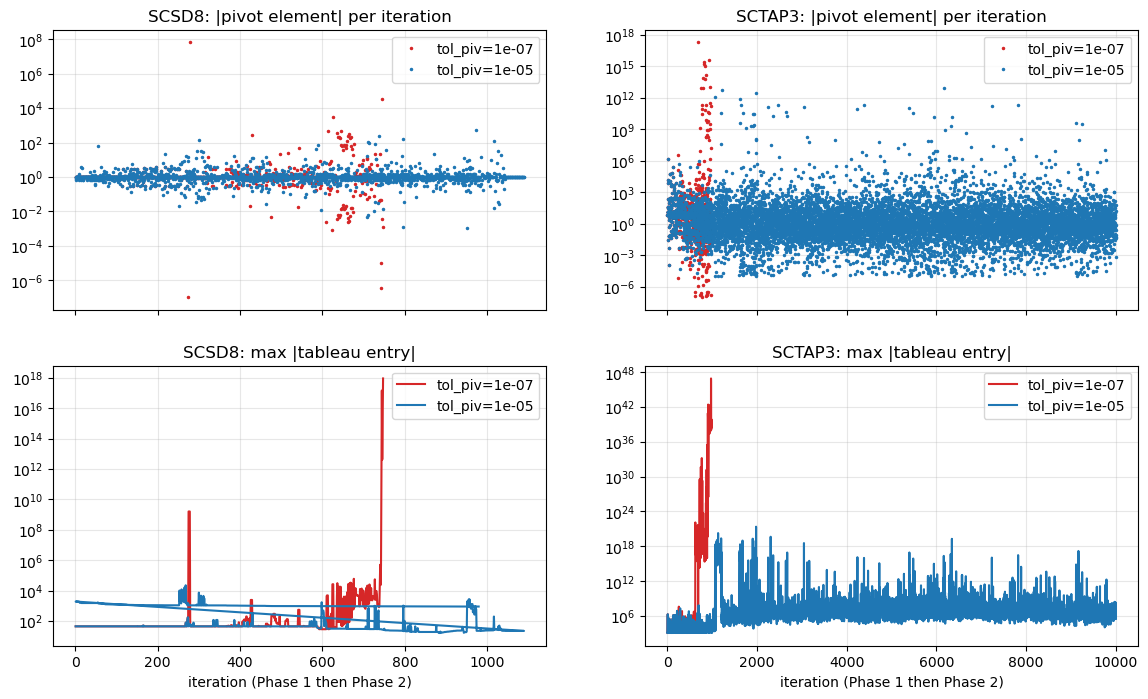

In [20]:
from quantecon.optimize import PivOptions
from quantecon.optimize.linprog_simplex import _initialize_tableau, _set_criterion_row, _pivot_col
from quantecon.optimize.pivoting import _lex_min_ratio_test, _pivoting
import run_grid


def traced_solve(name, piv_options, max_iter=10_000):
    """linprog_simplex with a per-iteration log of (phase, |pivot|, max |tableau|)."""
    p = run_grid.load_problem(name)
    n, m, k = p['c'].shape[0], p['A_ub'].shape[0], p['A_eq'].shape[0]
    L = m + k
    tableau = np.empty((L + 1, n + m + L + 1)); basis = np.empty(L, dtype=np.int_)
    argmins = np.empty(L, dtype=np.int_)
    _initialize_tableau(p['A_ub'], p['b_ub'], p['A_eq'], p['b_eq'], tableau, basis)
    log = []

    def run(skip_aux, phase):
        for it in range(1, max_iter + 1):
            found, pc = _pivot_col(tableau, skip_aux, piv_options)
            if not found:
                return 0
            found, pr = _lex_min_ratio_test(tableau[:-1, :], pc, tableau.shape[1] - L - 1, argmins,
                                            piv_options.tol_piv, piv_options.tol_ratio_diff)
            if not found:
                log.append((phase, it, np.nan, np.abs(tableau).max(), tableau[:-1, pc].max()))
                return 3
            log.append((phase, it, abs(tableau[pr, pc]), np.abs(tableau).max(), np.nan))
            _pivoting(tableau, pc, pr); basis[pr] = pc
        return 1

    status = run(False, 1)
    if status == 0:
        for i in range(L):  # eliminate artificial variables left in the basis
            if basis[i] >= n + m:
                for j in range(n + m):
                    if abs(tableau[i, j]) > piv_options.tol_piv:
                        _pivoting(tableau, j, i); basis[i] = j; break
        _set_criterion_row(p['c'], basis, tableau)
        status = run(True, 2)
    return status, pd.DataFrame(log, columns=['phase', 'iter', 'abs_pivot', 'max_abs_tableau', 'pivcol_max'])


fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col')
for j, name in enumerate(['SCSD8', 'SCTAP3']):
    for tp, color in [(1e-7, 'C3'), (1e-5, 'C0')]:
        status, log = traced_solve(name, PivOptions(1e-6, tp, 1e-13))
        piv = log.abs_pivot.dropna()
        print(f'{name} tol_piv={tp:.0e}: status {status}, {len(log)} iterations, smallest pivot {piv.min():.1e}, '
              f'pivots < 1e-5: {(piv < 1e-5).sum()}, max|tableau| {log.max_abs_tableau.iloc[0]:.1e} -> {log.max_abs_tableau.iloc[-1]:.1e}')
        axes[0, j].semilogy(log['iter'], log.abs_pivot, '.', ms=3, color=color, label=f'tol_piv={tp:.0e}')
        axes[1, j].semilogy(log['iter'], log.max_abs_tableau, color=color, label=f'tol_piv={tp:.0e}')
    axes[0, j].set_title(f'{name}: |pivot element| per iteration'); axes[1, j].set_title(f'{name}: max |tableau entry|')
    axes[1, j].set_xlabel('iteration (Phase 1 then Phase 2)')
    for ax in axes[:, j]: ax.legend(); ax.grid(alpha=.3)

## Equilibration experiment

If the problem is the *scale* of the tableau relative to an absolute tolerance, then rescaling the problem
data should help as much as loosening the tolerance. `scaling_experiment.py` divides each row of
`[A_ub; A_eq]` (and the corresponding `b`) by its largest absolute entry, then each column (and the
corresponding entry of `c`) by its largest absolute entry, and solves with `max_iter = 10_000`. The
optimal value is invariant to this scaling. Results for the 15 problems that fail at the defaults or are
borderline (`results_2026_scaling.csv`):

In [21]:
sc = pd.read_csv('results_2026_scaling.csv')
t = sc.pivot_table(index='problem', columns=['tol_piv', 'scaled'], values='solved', aggfunc='first').astype(int)
t.loc['TOTAL solved'] = t.sum()
st = sc.pivot_table(index='problem', columns=['tol_piv', 'scaled'], values='status', aggfunc='first')
display(t); print('exit status (0 optimal, 1 max_iter, 2 infeasible, 3 unbounded):'); st

tol_piv      1.000000e-07       1.000000e-05      
scaled              False True         False True 
problem                                           
25FV47                  0     1            0     1
BANDM                   1     1            1     1
BNL1                    1     1            1     1
BRANDY                  1     1            1     1
D2Q06C                  0     0            0     0
DEGEN2                  0     0            0     0
FFFFF800                0     1            1     1
SCAGR25                 1     1            1     1
SCFXM3                  1     1            1     1
SCSD1                   1     1            1     1
SCSD8                   0     0            1     0
SCTAP2                  0     1            0     1
SCTAP3                  0     1            0     1
WOOD1P                  0     0            0     0
WOODW                   0     1            0     1
TOTAL solved            6    11            8    11

exit status (0 optimal, 1 max_iter, 2 infeasible, 3 unbounded):


tol_piv  1.000000e-07       1.000000e-05      
scaled          False True         False True 
problem                                       
25FV47              3     0            1     0
BANDM               0     0            0     0
BNL1                0     0            0     0
BRANDY              0     0            0     0
D2Q06C              3     1            1     1
DEGEN2              1     1            1     1
FFFFF800            2     0            0     0
SCAGR25             0     0            0     0
SCFXM3              0     0            0     0
SCSD1               0     0            0     0
SCSD8               3     3            0     3
SCTAP2              3     0            3     0
SCTAP3              3     0            1     0
WOOD1P              3     1            3     1
WOODW               3     0            1     0

Scaling lets `tol_piv = 1e-7` solve 25FV47, FFFFF800, SCTAP2, SCTAP3 and WOODW, as many problems in
total as `tol_piv = 1e-5`, and it also solves SCTAP2, which no unscaled tolerance setting solved, while
turning WOOD1P's false "unbounded" into a `max_iter` exit. It is not a cure-all: SCSD8, which is solved
unscaled at 1e-5, fails scaled at both tolerances, because the pivot path changes and meets a different
small pivot. Scaling and a pivot-size-aware ratio test address the same root cause from two sides.

## Summary

1. **Reported `success` is trustworthy except at `tol_piv = 1e-3`.** With the HiGHS reference, no solve
   below 1e-3 reports success with a grossly wrong value except sporadic cases on SCAGR25, BANDM and
   WOOD1P; at 1e-3, AGG, AGG3, ISRAEL and LOTFI return confidently wrong optima. The two apparent
   false positives against the Netlib reference, SCRS8 and STOCFOR3, were errors in the stored values.
2. **`tol_piv` is the only tolerance with a large effect**, monotone up to 1e-4: the mean number solved
   per combination rises from 29.7 at 1e-10 to 41.9 at 1e-4, then drops to 37.8 at 1e-3. `fea_tol` is
   irrelevant in {1e-5, 1e-6, 1e-7}. The current default 1e-7 gives 37.7 on average.
3. **The mechanism is small pivots, not zero detection.** A pivot element of size 1e-7 multiplies its
   row by 1e7; after one or two such pivots the tableau grows by 15 to 35 orders of magnitude and the
   "unbounded" verdict (12.6% of all solves, 36% at `tol_piv = 1e-10`, 1% at 1e-4) is taken on garbage.
   Conversely, too large a `tol_piv` skips rows with genuinely positive entries, so the step can leave
   the feasible region, which is why 1e-3 produces wrong optima that pass the optimality test.
4. **Whether 1e-7 is "small" depends on the scale of the problem.** Equilibrating the data lets 1e-7
   solve as many of the hard problems as 1e-5 does, and solves SCTAP2, which no tolerance solved.
5. **`max_iter = 10_000` was too small**, not the solver: with 100,000 iterations 25FV47 (14-17k),
   BNL2 (17-19k), TRUSS (17-21k) and D2Q06C (50-54k) are solved at the looser pivot tolerances. DEGEN3
   and QAP8 still fail; so do QAP12, QAP15 and STOCFOR3 within 10,000 iterations.
6. **`tol_ratio_diff` matters on degenerate problems, in both directions.** 1e-11 is best on average
   at 10,000 iterations and solves DEGEN2 in 2,847 iterations where 1e-13 stalls for 100,000, but 1e-13
   solves TRUSS where 1e-11 ends in a false "unbounded". DEGEN3 fails either way.
7. **Changing the default `tol_piv` from 1e-7 to 1e-5 is safe on this test set**: no problem solved at
   1e-7 is lost, and on the 38 problems both solve, the objective values agree to 1e-12 and the pivot
   paths are identical on 35 to 37 of them. It is nevertheless a workaround for a scale problem. The
   robust fix, for the refactor of `pivoting.py`, is to make the ratio test prefer large pivots among
   near-minimal ratios (Harris-style two-pass test) or to use tolerances relative to the scale of the
   tableau, possibly together with equilibration of the input data. WOOD1P, SCTAP2, SCSD8 and DEGEN3
   are the test cases to keep.